# EDA

In [85]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


path = kagglehub.dataset_download("yasserh/loan-default-dataset")
file_path = os.path.join(path, "Loan_Default.csv")
data = pd.read_csv(file_path)

In [86]:
cat_cols = [col for col in data.columns if data[col].dtype in ['str', 'category']]
num_cols = [col for col in data.columns if data[col].dtype in ['int64', 'float64']]

num_cols.remove('Status') 
num_cols.remove('ID') 
num_cols.remove('year') 

num_cols_with_target = num_cols.copy()
num_cols_with_target.append('Status')

### Analysis of numerical feature

 correlation matrix of numerical features

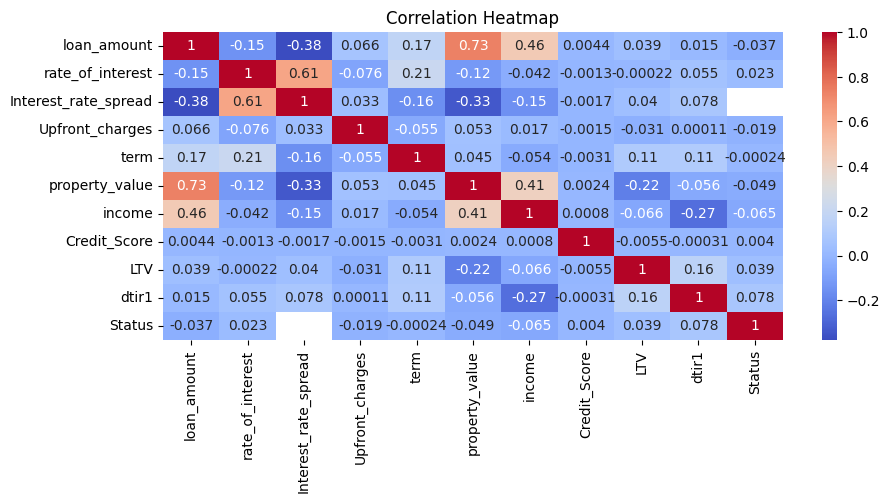

In [87]:
correlation_matrix = data[num_cols_with_target].corr()

# Visualizing correlation heatmap
plt.figure(figsize=(10,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Histogram of numerical features(to show the distribution of features)

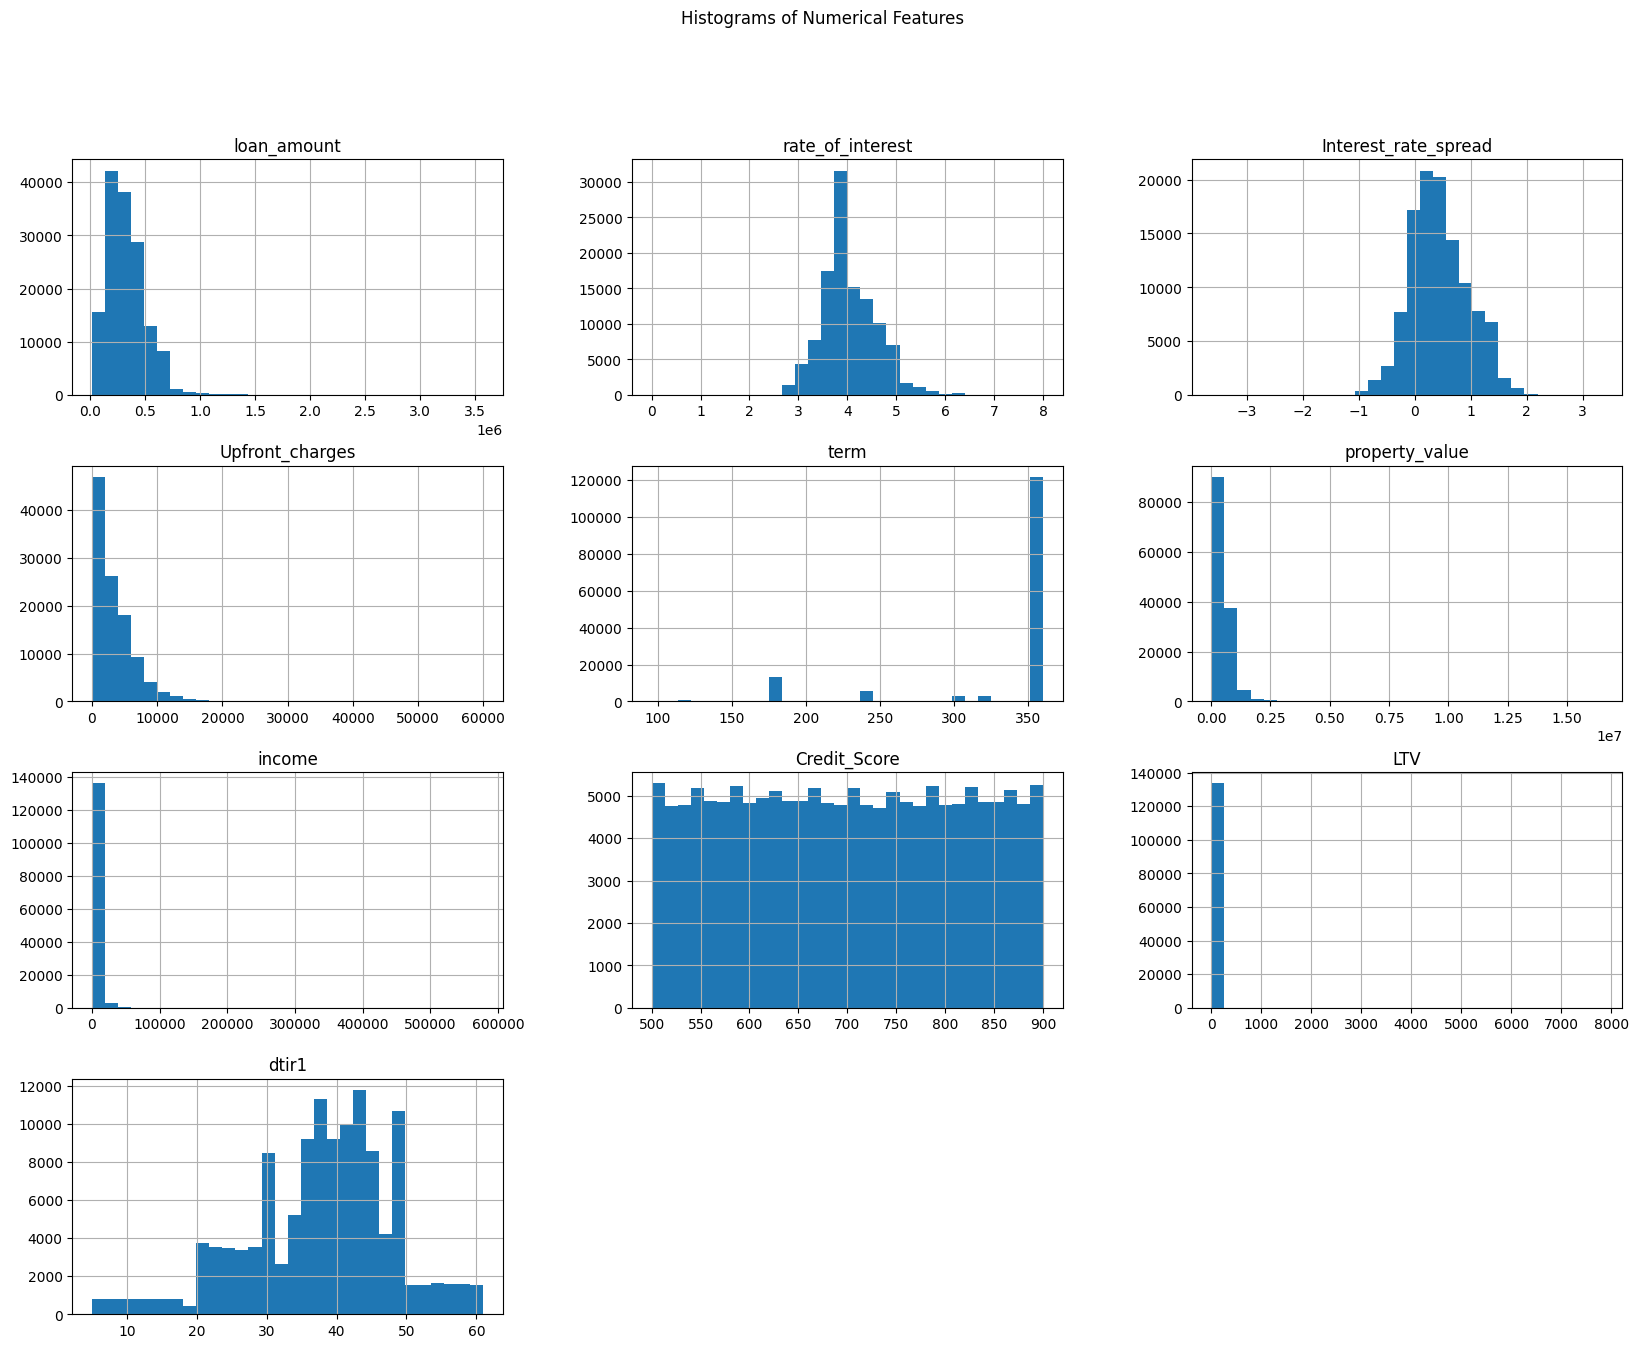

In [88]:
data[num_cols].hist(bins=30, figsize=(20, 15))
plt.suptitle('Histograms of Numerical Features')
plt.show()

Boxplot to understand the skewness potential outliers of the numerical feature

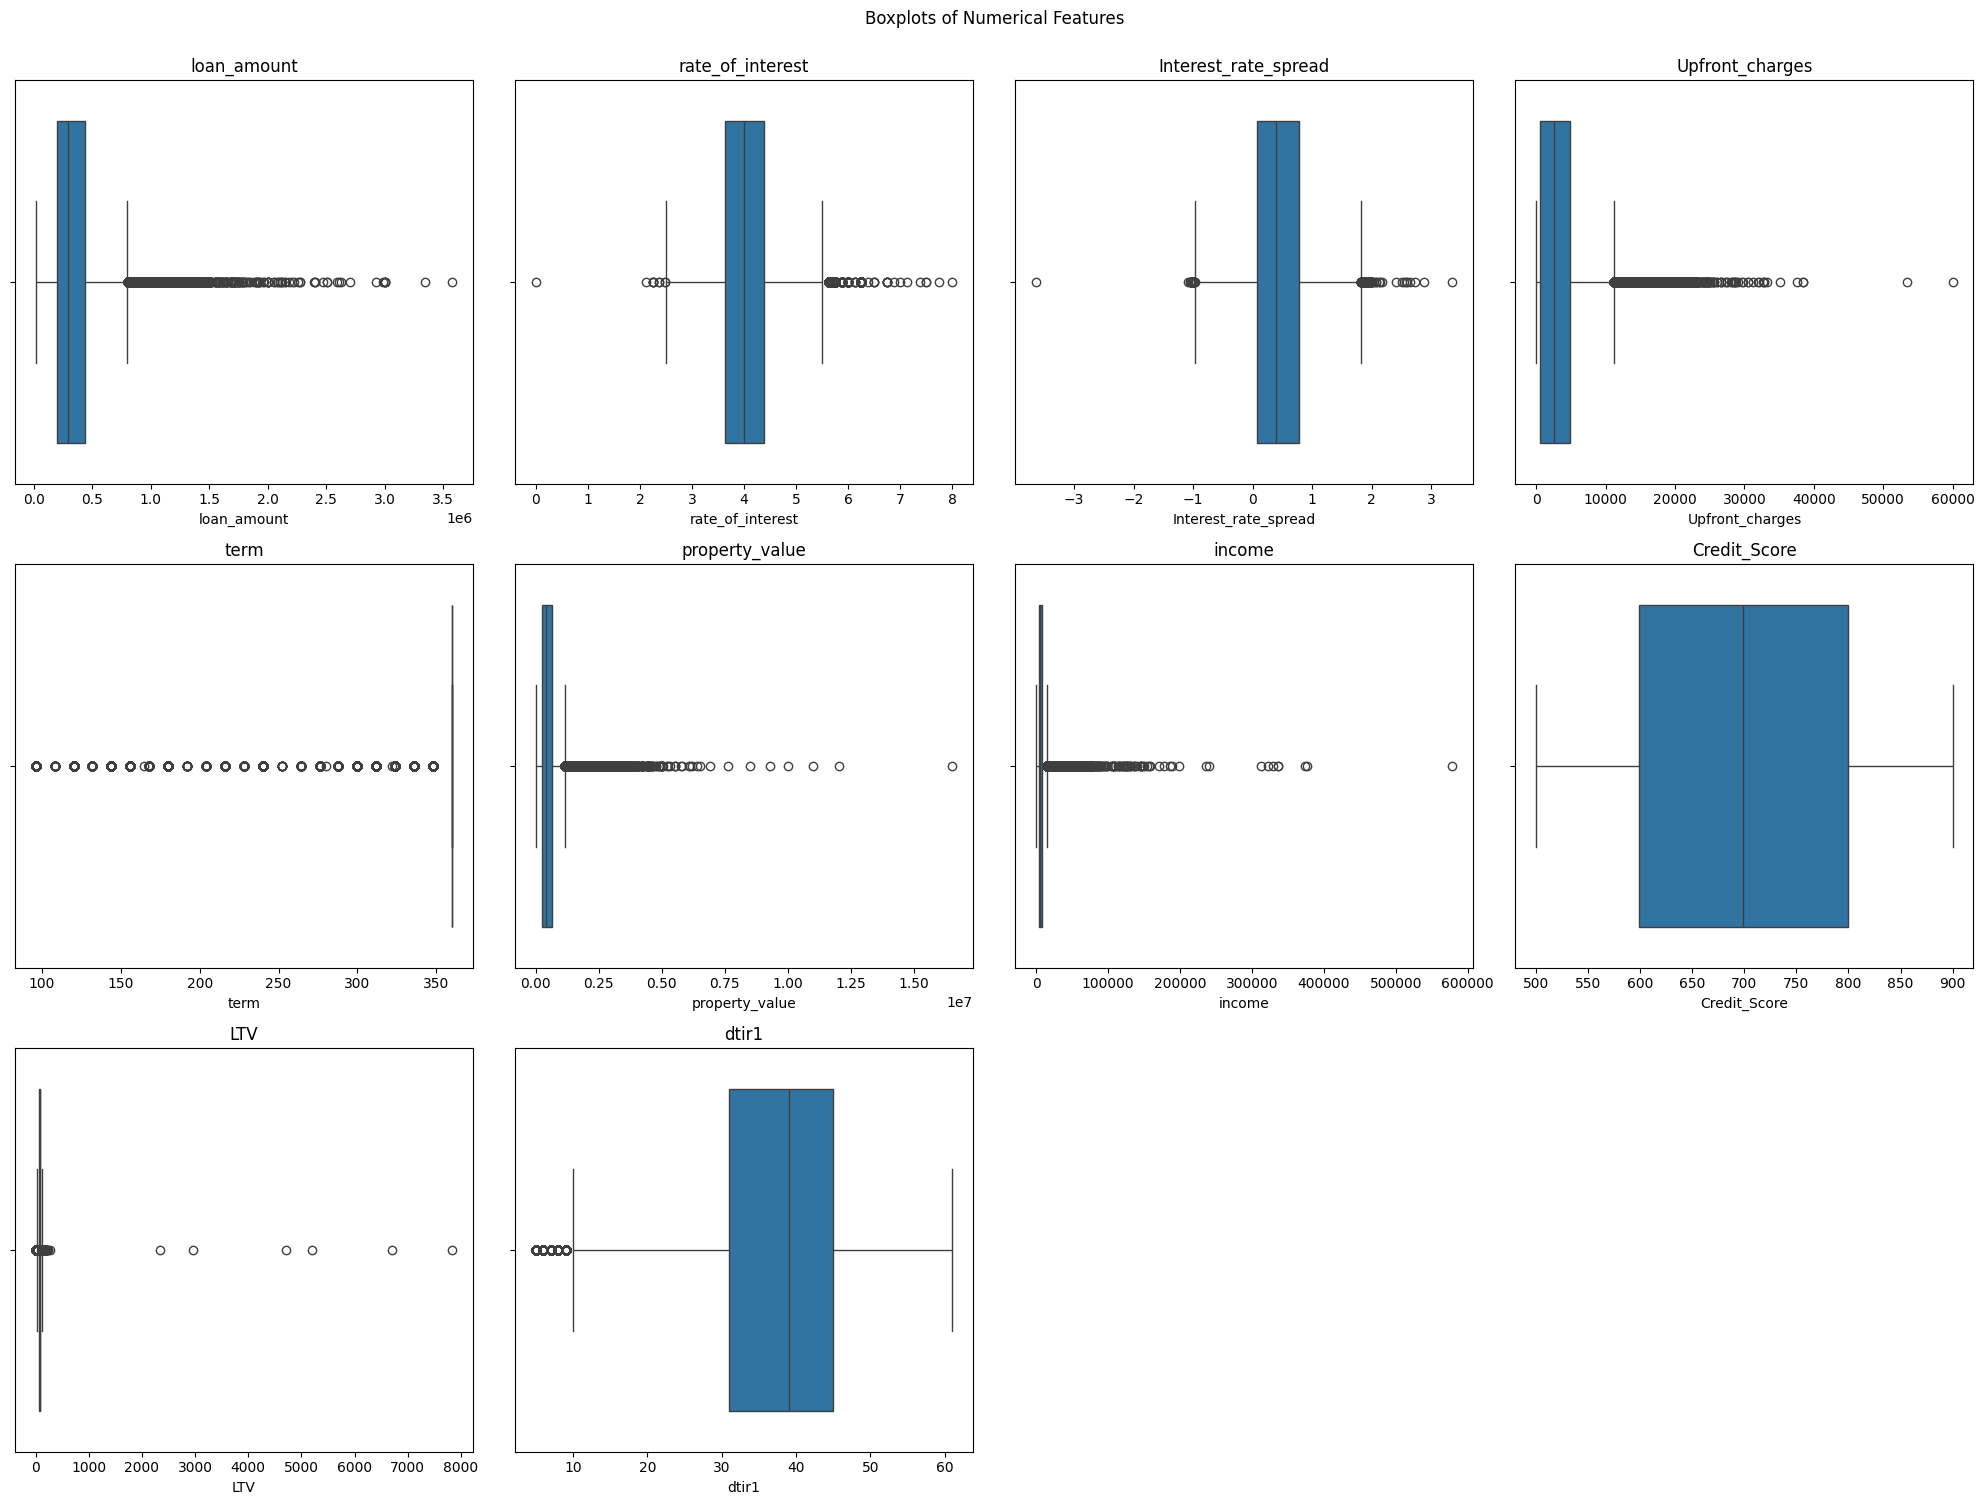

In [89]:
plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,4, i)
    sns.boxplot(x=data[col])
    plt.title(col)
plt.suptitle('Boxplots of Numerical Features', y = 1)
plt.tight_layout()
plt.show()

In [90]:
data[num_cols].isnull().sum()

loan_amount                 0
rate_of_interest        36439
Interest_rate_spread    36639
Upfront_charges         39642
term                       41
property_value          15098
income                   9150
Credit_Score                0
LTV                     15098
dtir1                   24121
dtype: int64

In [91]:
status_upfront_summary = data.groupby('Status')['property_value'].apply(lambda x: x.isnull().sum())
print(status_upfront_summary)

Status
0        2
1    15096
Name: property_value, dtype: int64


In [92]:
data["income"] = data["income"].fillna(data["income"].median())
#zero_charges = data[data['Upfront_charges'] == 0].shape[0]
#print(zero_charges)

In [93]:
data["income"].corr(data["Status"])

np.float64(-0.06061815355487695)

## Analysis of categorical features


In [94]:
for col in cat_cols:
    print(f"Unique values in {col}: {data[col].unique()}")

Unique values in loan_limit: <StringArray>
['cf', nan, 'ncf']
Length: 3, dtype: str
Unique values in Gender: <StringArray>
['Sex Not Available', 'Male', 'Joint', 'Female']
Length: 4, dtype: str
Unique values in approv_in_adv: <StringArray>
['nopre', 'pre', nan]
Length: 3, dtype: str
Unique values in loan_type: <StringArray>
['type1', 'type2', 'type3']
Length: 3, dtype: str
Unique values in loan_purpose: <StringArray>
['p1', 'p4', 'p3', 'p2', nan]
Length: 5, dtype: str
Unique values in Credit_Worthiness: <StringArray>
['l1', 'l2']
Length: 2, dtype: str
Unique values in open_credit: <StringArray>
['nopc', 'opc']
Length: 2, dtype: str
Unique values in business_or_commercial: <StringArray>
['nob/c', 'b/c']
Length: 2, dtype: str
Unique values in Neg_ammortization: <StringArray>
['not_neg', 'neg_amm', nan]
Length: 3, dtype: str
Unique values in interest_only: <StringArray>
['not_int', 'int_only']
Length: 2, dtype: str
Unique values in lump_sum_payment: <StringArray>
['not_lpsm', 'lpsm']
Leng

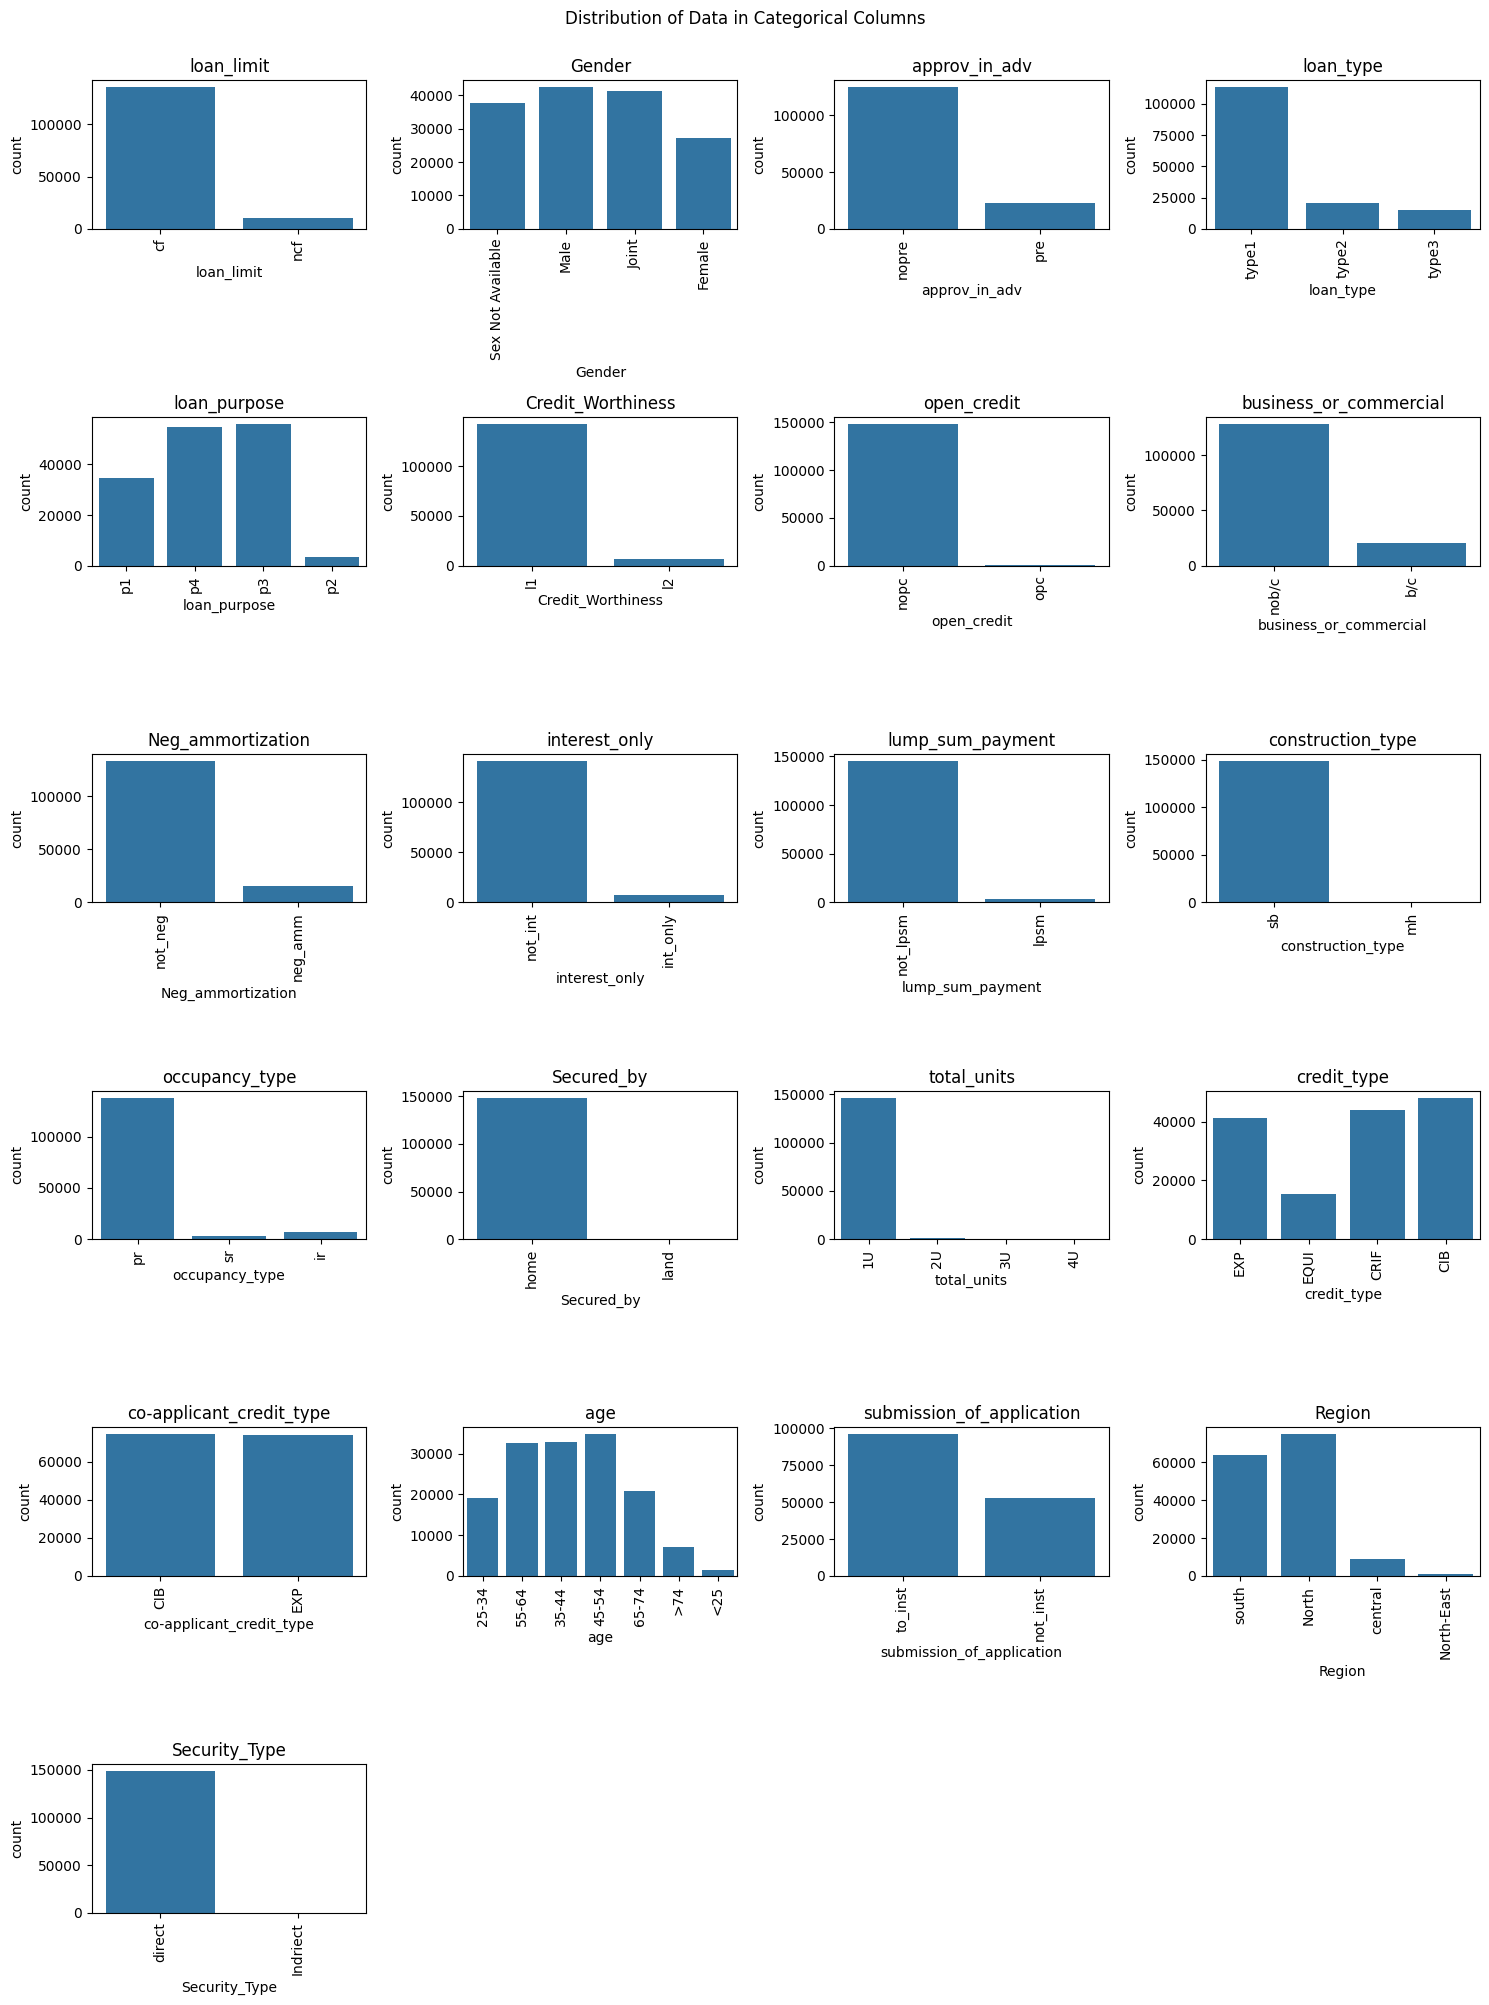

In [95]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols, 1):

    plt.subplot(6,4, i)
    sns.countplot(data=data, x=col)
    plt.title(col)
    plt.xticks(rotation=90)
    plt.suptitle("Distribution of Data in Categorical Columns", y=1)
plt.tight_layout()
plt.show()

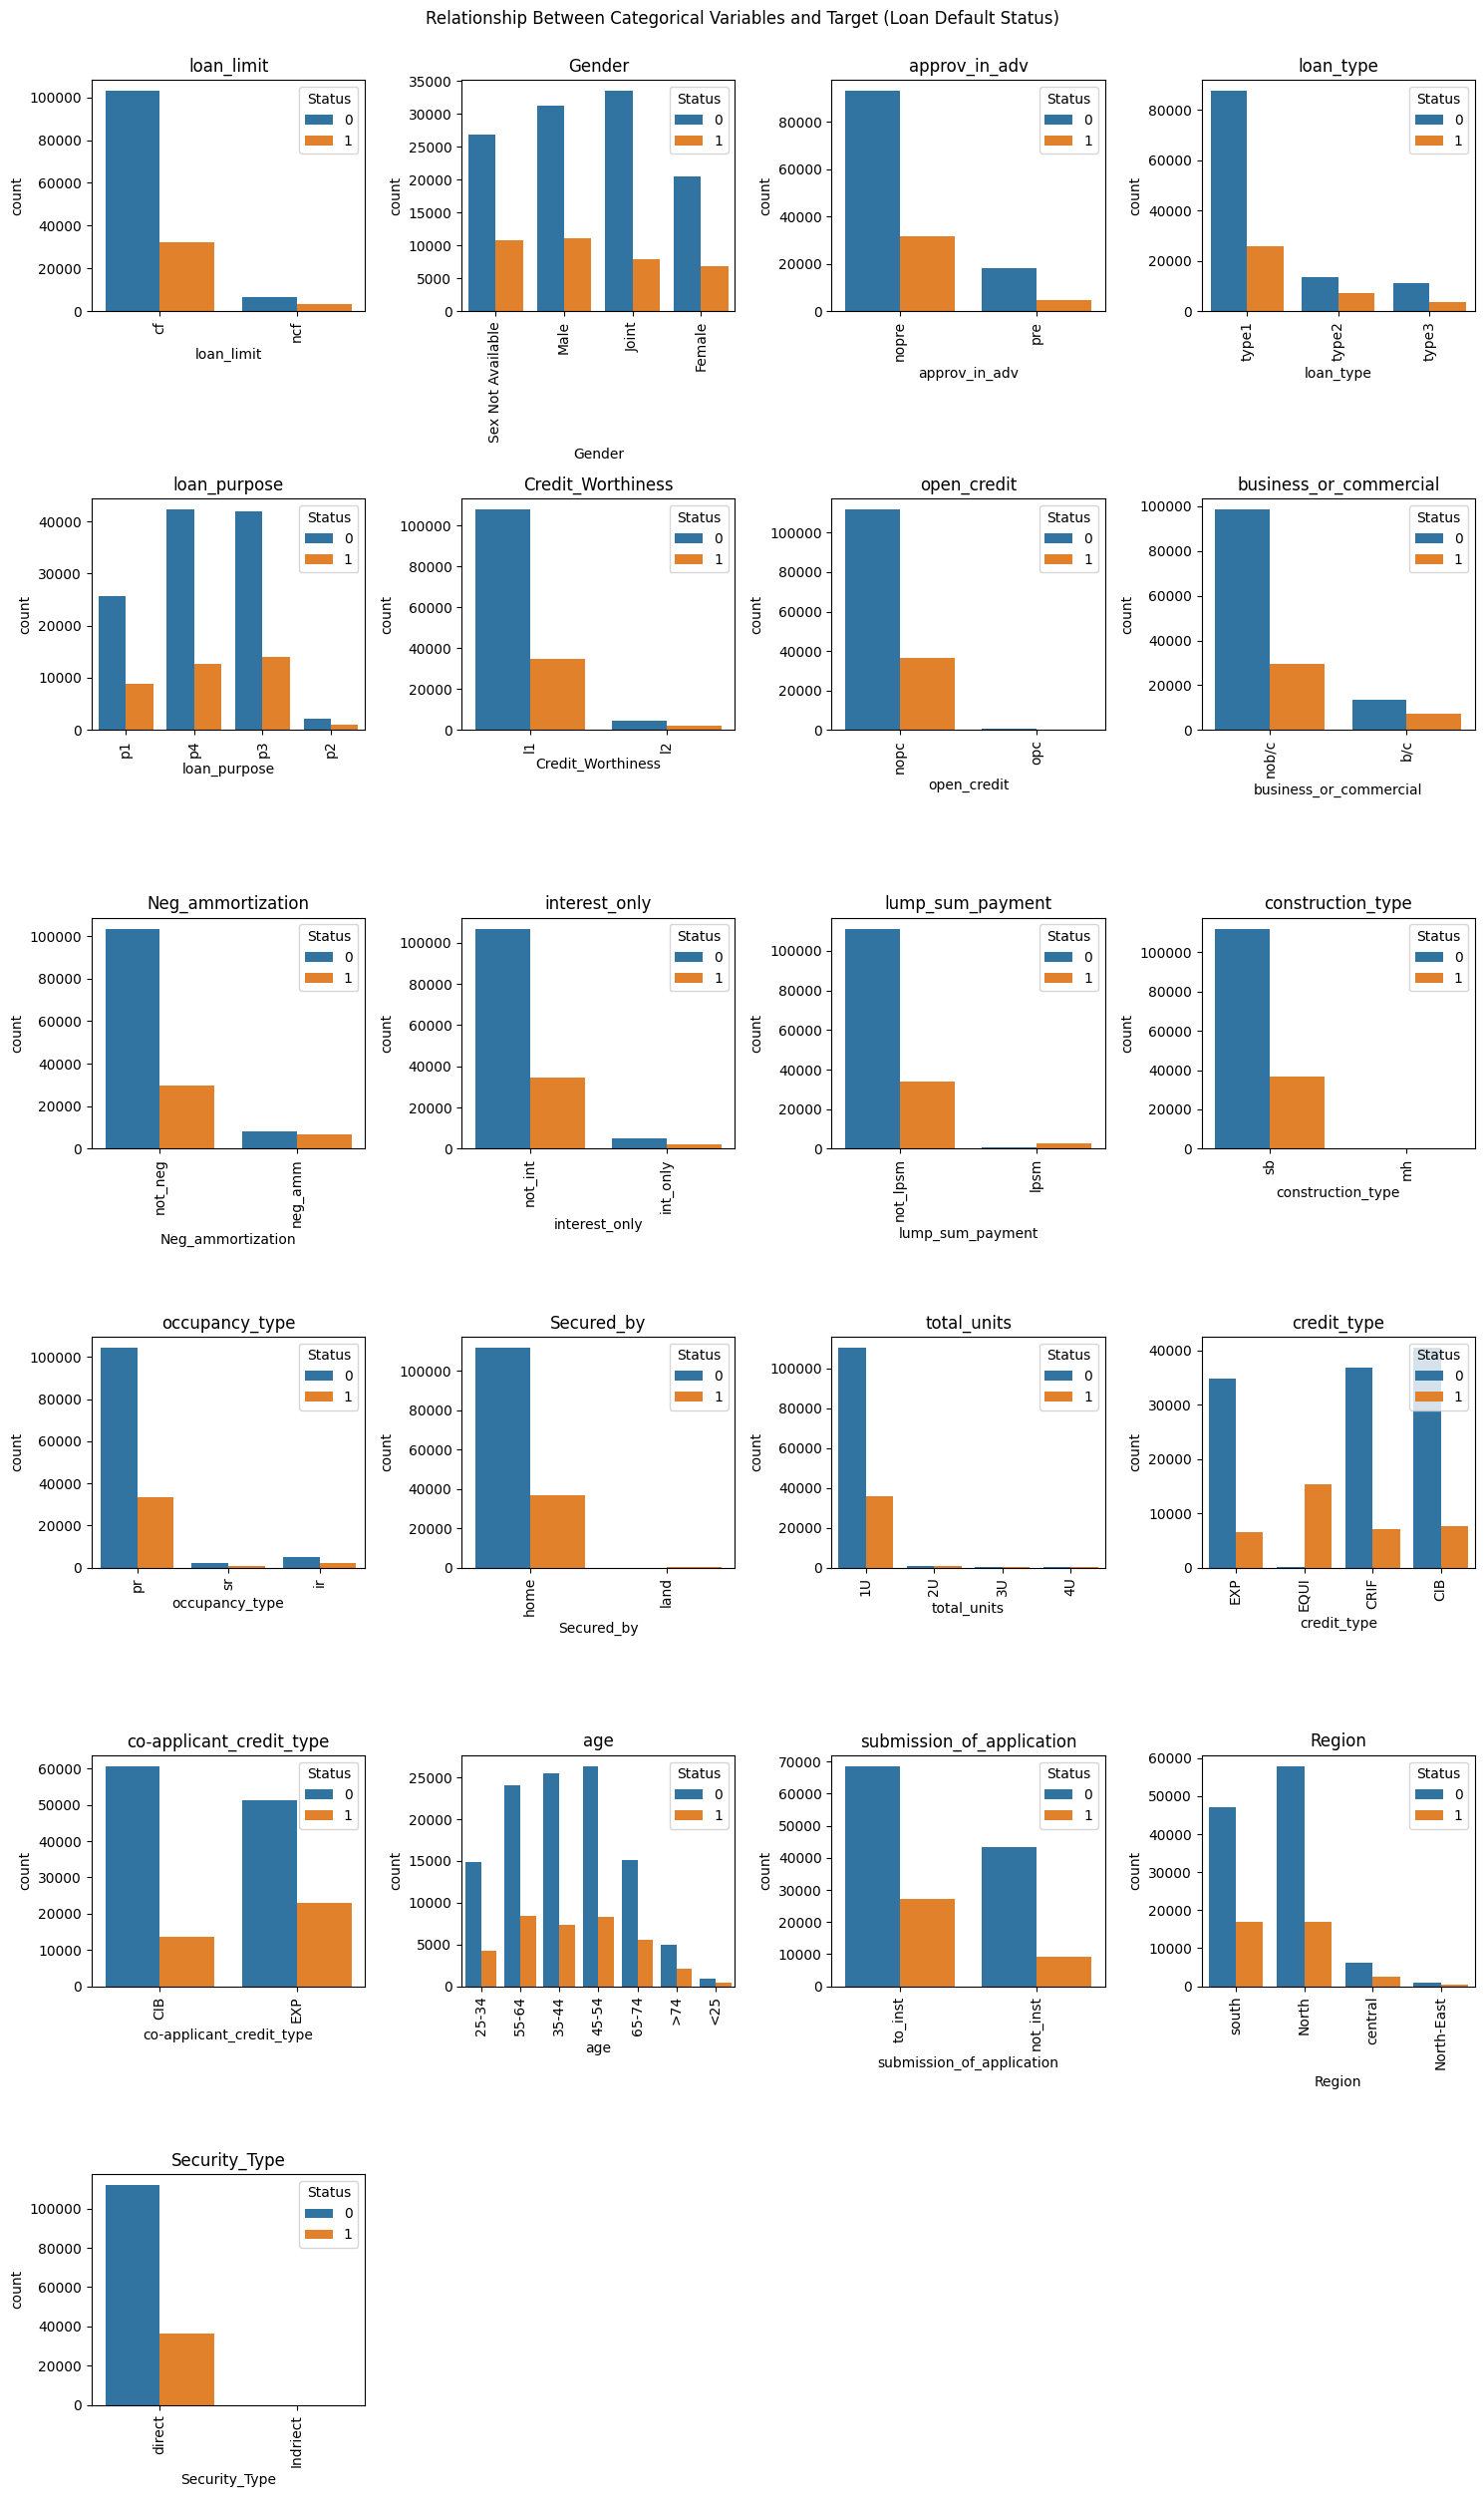

In [96]:
plt.figure(figsize=(15, 25))
for i, col in enumerate(cat_cols, 1):

    plt.subplot(6,4, i)
    sns.countplot(data=data, x=col, hue='Status')
    plt.title(col)
    plt.xticks(rotation=90)
plt.suptitle("Relationship Between Categorical Variables and Target (Loan Default Status)", y=1)   
plt.tight_layout()
plt.show()

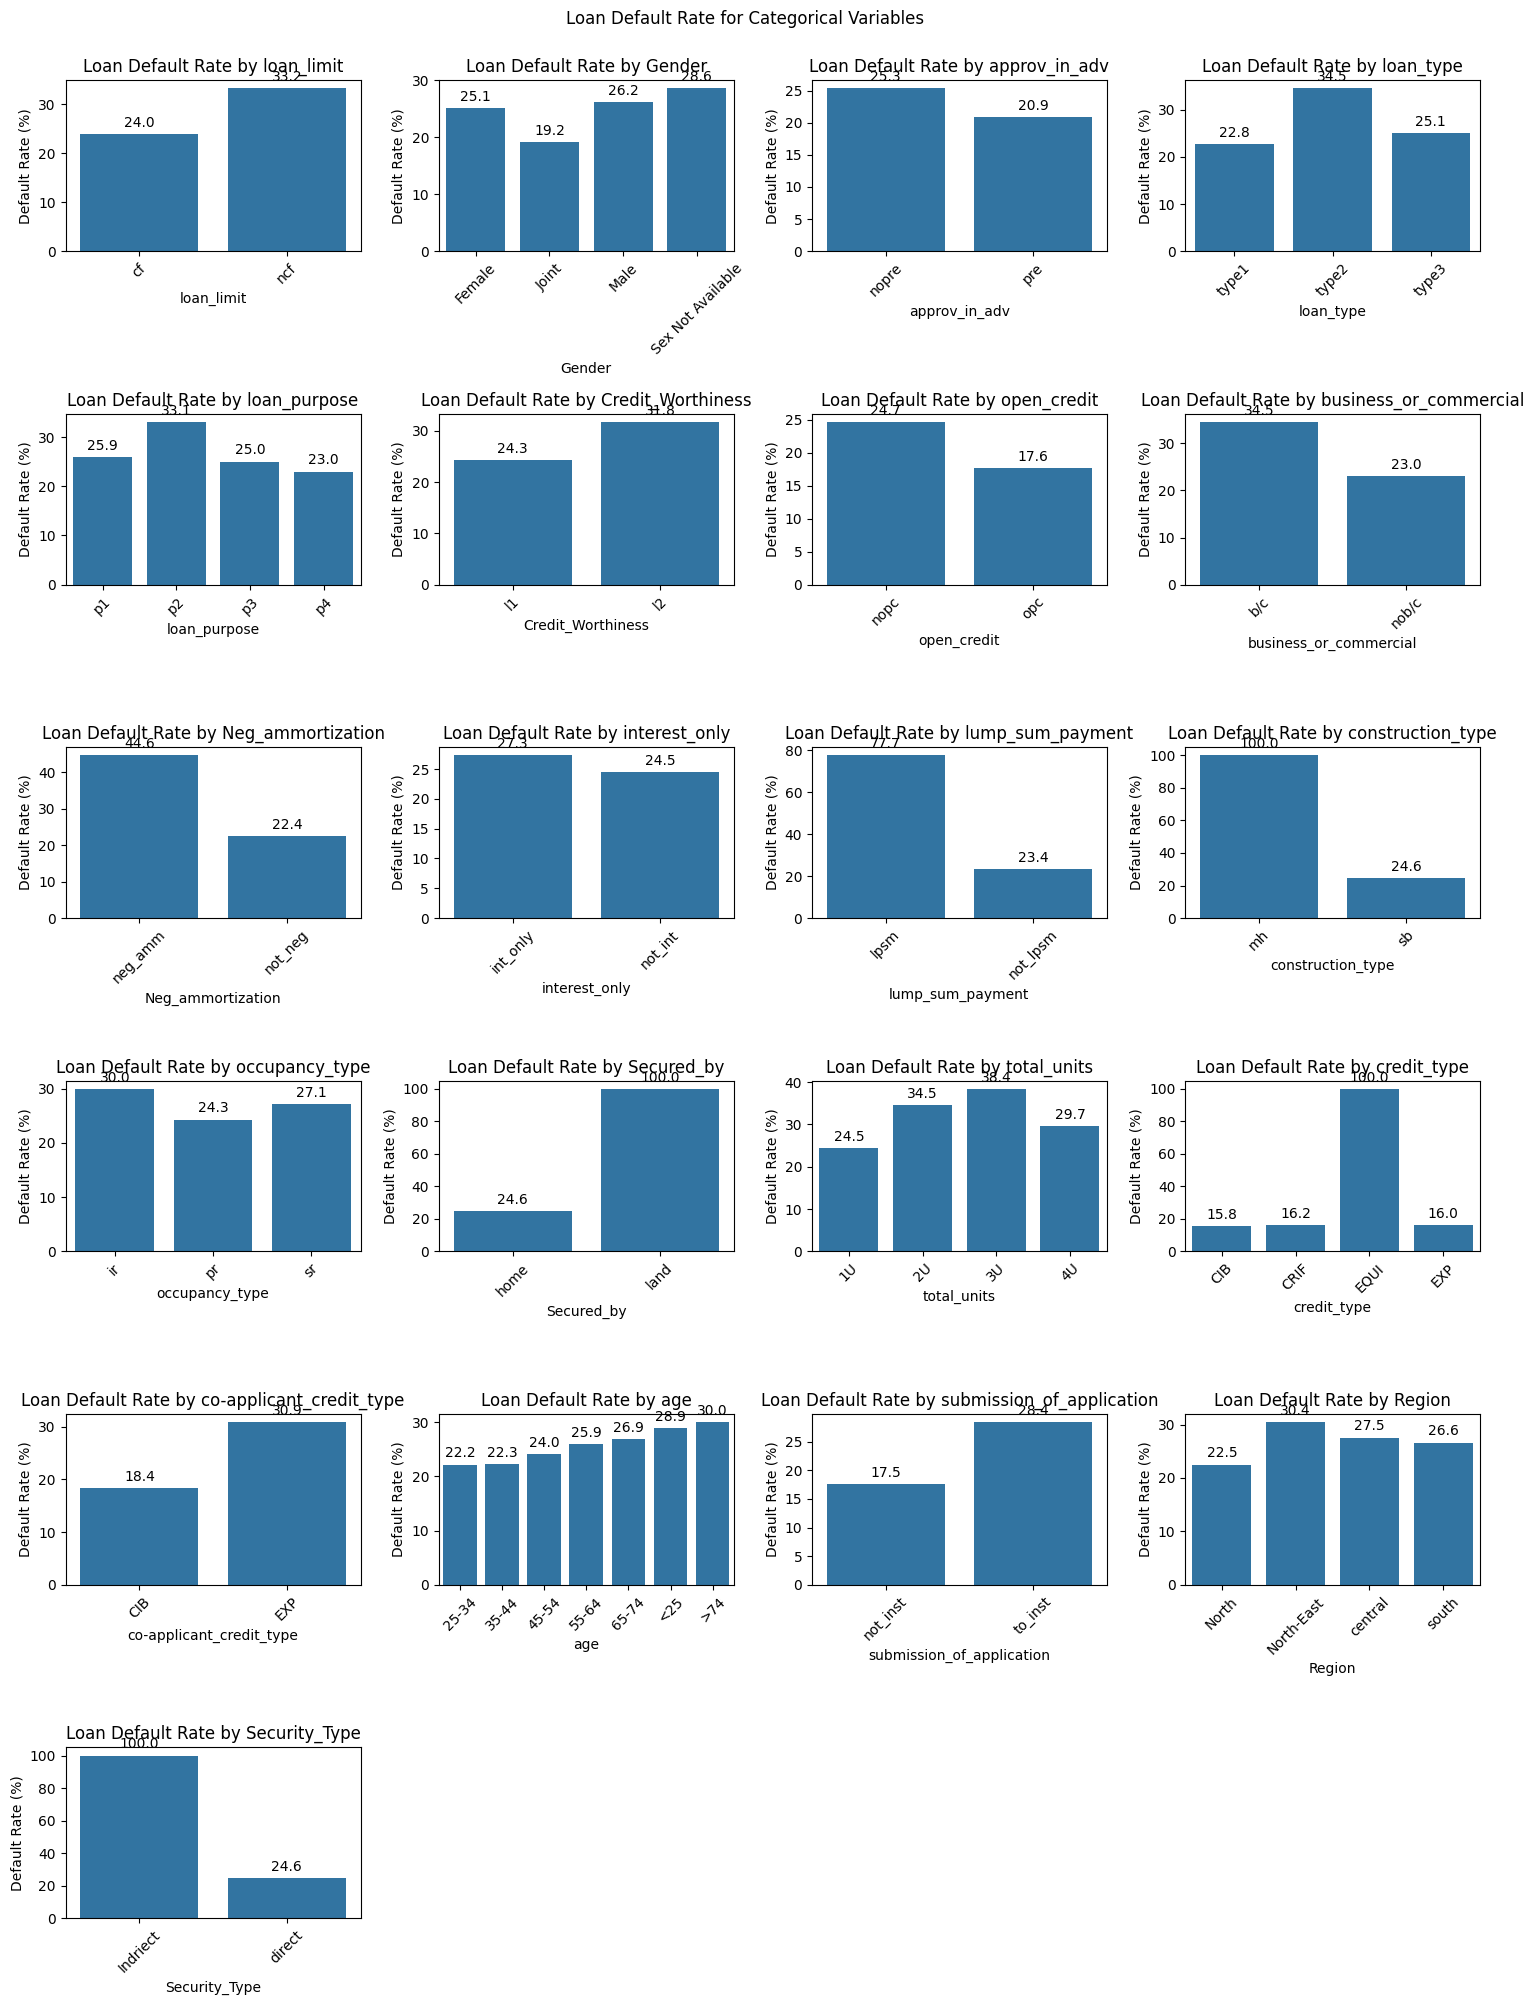

In [97]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(cat_cols, 1):
    
    default_rate = data.groupby(col)['Status'].mean() * 100
    plt.subplot(6,4, i)
    ax = sns.barplot(x = default_rate.index, y = default_rate.values)
    ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
    plt.title(f"Loan Default Rate by {col}")
    plt.ylabel("Default Rate (%)")
    plt.xticks(rotation=45)
plt.suptitle("Loan Default Rate for Categorical Variables", y=1)   
plt.tight_layout()
plt.show()

In [99]:
data[cat_cols].isnull().sum().sort_values(ascending = False)

loan_limit                   3344
approv_in_adv                 908
submission_of_application     200
age                           200
loan_purpose                  134
Neg_ammortization             121
occupancy_type                  0
Region                          0
co-applicant_credit_type        0
credit_type                     0
total_units                     0
Secured_by                      0
lump_sum_payment                0
construction_type               0
Gender                          0
interest_only                   0
business_or_commercial          0
open_credit                     0
Credit_Worthiness               0
loan_type                       0
Security_Type                   0
dtype: int64